In [1]:
import pandas as pd
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score

In [2]:
root_path = "/home/stefan/ioai-prep/kits/calitate_sol"

seed = 42

# Data

In [3]:
train_df = pd.read_csv(f"{root_path}/train_data.csv")
test_df = pd.read_csv(f"{root_path}/test_data.csv")

train_df.head()

,ID,Soil_Type,Region,Irrigation,pH,Moisture,Nitrogen,Phosphorus,Potassium,Organic_Matter,Electrical_Conductivity,Bulk_Density,Clay_Percent,Temperature,Rainfall_7d,Sunlight_hours,Slope,Suitability
0,1,Sandy,Hill,Sprinkler,6.501,25.144,45.528,33.742,122.187,NaN,0.472,1.697,6.190,19.980,23.595,6.439,6.823,Unfavorable
1,2,Clay,Plain,Sprinkler,6.322,22.391,119.376,62.453,218.362,2.464,1.786,1.350,41.372,25.102,5.063,10.392,1.038,Favorable
2,3,Sandy,Hill,Sprinkler,6.847,23.489,74.258,36.014,120.864,2.596,1.270,1.627,1.000,17.128,18.410,8.126,7.177,Favorable
3,4,Loam,Plain,Sprinkler,6.697,30.294,90.570,66.035,198.206,2.899,0.596,1.302,32.664,22.799,24.588,7.034,0.000,Favorable
4,5,Clay,Hill,NaN,6.740,24.471,81.934,58.793,142.101,4.334,1.289,1.402,53.710,15.147,7.216,4.151,14.352,Favorable


In [4]:
train_df.isna().sum().sort_values(ascending=False)

Irrigation                 1181
Organic_Matter              220
Moisture                    170
ID                            0
Soil_Type                     0
Region                        0
pH                            0
Nitrogen                      0
Phosphorus                    0
Potassium                     0
Electrical_Conductivity       0
Bulk_Density                  0
Clay_Percent                  0
Temperature                   0
Rainfall_7d                   0
Sunlight_hours                0
Slope                         0
Suitability                   0
dtype: int64

# Subtask 1

Nutrient_Index = 0.4 * Nitrogen + 0.3 * Phosphorus + 0.3 * Potassium.

In [5]:
subtask1 = 0.4 * test_df["Nitrogen"] + 0.3 * test_df["Phosphorus"] + 0.3 * test_df["Potassium"]

# Subtask 2

- Acid dacă pH < 6.0
- Neutral dacă 6.0 ≤ pH ≤ 7.5
- Alkaline dacă pH > 7.5

In [6]:
def cls_ph(ph):
    if ph < 6.0:
        return "Acid"
    if ph <= 7.5:
        return "Neutral"
    return "Alkaline"

subtask2 = test_df["pH"].apply(cls_ph)

<Axes: xlabel='pH', ylabel='Count'>

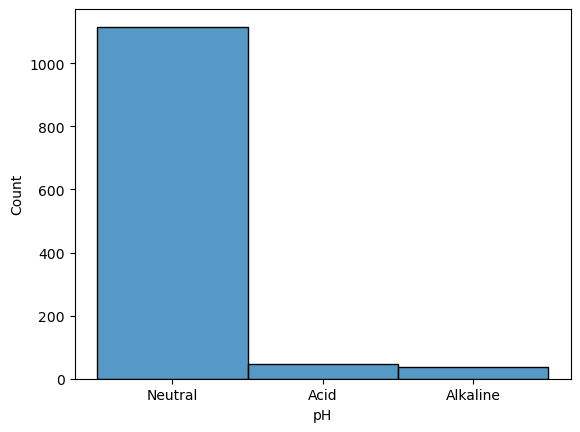

In [7]:
sns.histplot(subtask2)

# Subtask 3

In [8]:
moistures = train_df["Moisture"][train_df["Moisture"].notna()]
train_moisture = moistures.median()

subtask3 = (test_df["Moisture"] > train_moisture).astype(int)

# Subtask 4

In [9]:
train_counts = train_df["Soil_Type"].value_counts()

In [10]:
subtask4 = test_df["Soil_Type"].map(train_counts)

# Subtask 5

In [11]:
train_df.head()

,ID,Soil_Type,Region,Irrigation,pH,Moisture,Nitrogen,Phosphorus,Potassium,Organic_Matter,Electrical_Conductivity,Bulk_Density,Clay_Percent,Temperature,Rainfall_7d,Sunlight_hours,Slope,Suitability
0,1,Sandy,Hill,Sprinkler,6.501,25.144,45.528,33.742,122.187,NaN,0.472,1.697,6.190,19.980,23.595,6.439,6.823,Unfavorable
1,2,Clay,Plain,Sprinkler,6.322,22.391,119.376,62.453,218.362,2.464,1.786,1.350,41.372,25.102,5.063,10.392,1.038,Favorable
2,3,Sandy,Hill,Sprinkler,6.847,23.489,74.258,36.014,120.864,2.596,1.270,1.627,1.000,17.128,18.410,8.126,7.177,Favorable
3,4,Loam,Plain,Sprinkler,6.697,30.294,90.570,66.035,198.206,2.899,0.596,1.302,32.664,22.799,24.588,7.034,0.000,Favorable
4,5,Clay,Hill,NaN,6.740,24.471,81.934,58.793,142.101,4.334,1.289,1.402,53.710,15.147,7.216,4.151,14.352,Favorable


In [12]:
def prep_df(df: pd.DataFrame):
    y = df["Suitability"] if "Suitability" in df else None
    df = df.drop(["ID", "Suitability"], axis=1, errors='ignore')

    df["ph_class"] = df["pH"].apply(cls_ph) # most relevant
    df["index"] = 0.4 * df["Nitrogen"] + 0.3 * df["Phosphorus"] + 0.3 * df["Potassium"]

    missing_cols = df[df.isna()]
    for col in missing_cols:
        filler = df[col].mean() if df[col].dtype != 'str' else df[col].mode()
        df[col] = df[col].fillna(filler)

    cat_cols = df.select_dtypes(include='str').columns
    for col in cat_cols:
        dummies = pd.get_dummies(df[col], prefix=col, drop_first=True)
        df = pd.concat([df, dummies], axis=1)
        df = df.drop([col], axis=1)

    if y is not None:
        X = df
        return X, y
    return df

In [13]:
X, y = prep_df(train_df)

X.head()

,pH,Moisture,Nitrogen,Phosphorus,Potassium,Organic_Matter,Electrical_Conductivity,Bulk_Density,Clay_Percent,Temperature,...,Slope,index,Soil_Type_Loam,Soil_Type_Sandy,Soil_Type_Silt,Region_Mountain,Region_Plain,Irrigation_Sprinkler,ph_class_Alkaline,ph_class_Neutral
0,6.501,25.144,45.528,33.742,122.187,2.825001,0.472,1.697,6.190,19.980,...,6.823,64.9899,False,True,False,False,False,True,False,True
1,6.322,22.391,119.376,62.453,218.362,2.464000,1.786,1.350,41.372,25.102,...,1.038,131.9949,False,False,False,False,True,True,False,True
2,6.847,23.489,74.258,36.014,120.864,2.596000,1.270,1.627,1.000,17.128,...,7.177,76.7666,False,True,False,False,False,True,False,True
3,6.697,30.294,90.570,66.035,198.206,2.899000,0.596,1.302,32.664,22.799,...,0.000,115.5003,True,False,False,False,True,True,False,True
4,6.740,24.471,81.934,58.793,142.101,4.334000,1.289,1.402,53.710,15.147,...,14.352,93.0418,False,False,False,False,False,False,False,True


In [14]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=seed)

In [15]:
def evaluate(clf):
    clf.fit(X_train, y_train)
    preds = clf.predict(X_test)
    return f1_score(y_test, preds, pos_label="Unfavorable")

In [16]:
lr = LogisticRegression(max_iter=5000)

evaluate(lr)

0.8143322475570033

In [17]:
clf = lr
clf.fit(X, y)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [18]:
X_test_real = prep_df(test_df)
subtask5 = clf.predict(X_test_real)

# Submission

In [19]:
def build_subtask(sid, ans):
    return pd.DataFrame({
        "subtaskID": sid,
        "datapointID": test_df["ID"],
        "answer": ans
    })

subtasks = [
    (1, subtask1),
    (2, subtask2),
    (3, subtask3),
    (4, subtask4),
    (5, subtask5),
]

submission_df = pd.concat([build_subtask(sid, ans) for sid, ans in subtasks])

In [20]:
submission_df.head()

,subtaskID,datapointID,answer
0,1,2601,96.5909
1,1,2602,109.2507
2,1,2603,105.0137
3,1,2604,87.9858
4,1,2605,78.1208


In [21]:
submission_df.to_csv(f"{root_path}/submission.csv", index=False)